In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [11]:
teste = pd.read_csv(r'C:\Users\Pedro\Documents\GitHub\ML1_AV2_FinalProject\clean_data\test_clean.csv')
treino = pd.read_csv(r'C:\Users\Pedro\Documents\GitHub\ML1_AV2_FinalProject\clean_data\train_clean.csv')

teste0 = sm.add_constant(teste)

Comecei fazendo o probit com toda as variáveis.

In [12]:
X1 = treino.drop('SeriousDlqin2yrs', axis=1)
y = treino['SeriousDlqin2yrs']

X1 = sm.add_constant(X1)
probit_model1 = sm.Probit(y, X1)
probit_result1 = probit_model1.fit()

teste1 = teste0.drop(teste0.columns[[1]],axis=1)

df_t = pd.DataFrame({
    'real': teste['SeriousDlqin2yrs'],
    'Probit1': probit_result1.predict(teste1)
})
print(probit_result1.summary())

Optimization terminated successfully.
         Current function value: 0.234425
         Iterations 7
                          Probit Regression Results                           
Dep. Variable:       SeriousDlqin2yrs   No. Observations:               120269
Model:                         Probit   Df Residuals:                   120258
Method:                           MLE   Df Model:                           10
Date:                Mon, 10 Nov 2025   Pseudo R-squ.:                 0.07087
Time:                        12:41:10   Log-Likelihood:                -28194.
converged:                       True   LL-Null:                       -30345.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -0.9127      0.0

Percebendo que há variáveis com valor-P alto, fiz um novo modelo mas retirando os preditores com valor-P > .01

In [13]:
X2 = X1.drop(X1.columns[[1,4,6]], axis=1)

probit_model2 = sm.Probit(y, X2)
probit_result2 = probit_model2.fit()

teste2 = teste1.drop(teste1.columns[[1,4,6]],axis=1)

df_t['Probit2'] = probit_result2.predict(teste2)
print(probit_result2.summary())

Optimization terminated successfully.
         Current function value: 0.234475
         Iterations 7
                          Probit Regression Results                           
Dep. Variable:       SeriousDlqin2yrs   No. Observations:               120269
Model:                         Probit   Df Residuals:                   120261
Method:                           MLE   Df Model:                            7
Date:                Mon, 10 Nov 2025   Pseudo R-squ.:                 0.07067
Time:                        12:41:11   Log-Likelihood:                -28200.
converged:                       True   LL-Null:                       -30345.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -0.9217      0.0

Haviam 3 variáveis com correlação muito alta em cada combinação 2 a 2,então tentei inicialmente retirar 2 delas para ver se obtinha bons resultados.

In [14]:
X3 = X2.drop(X2.columns[[4,6]],axis=1)

X3.head()

probit_model3 = sm.Probit(y, X3)
probit_result3 = probit_model3.fit()

print(probit_result3.summary())

teste3 = teste2.drop(teste2.columns[[4,6]], axis=1)

df_t['Probit3'] = probit_result3.predict(teste3)

Optimization terminated successfully.
         Current function value: 0.242541
         Iterations 7
                          Probit Regression Results                           
Dep. Variable:       SeriousDlqin2yrs   No. Observations:               120269
Model:                         Probit   Df Residuals:                   120263
Method:                           MLE   Df Model:                            5
Date:                Mon, 10 Nov 2025   Pseudo R-squ.:                 0.03871
Time:                        12:41:12   Log-Likelihood:                -29170.
converged:                       True   LL-Null:                       -30345.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -0.8508      0.0

Média do Módulo da Diferença com probit 1: 0.0545
Média do Módulo da Diferença com probit 2: 0.0545
Média do Módulo da Diferença com probit 3: 0.0635


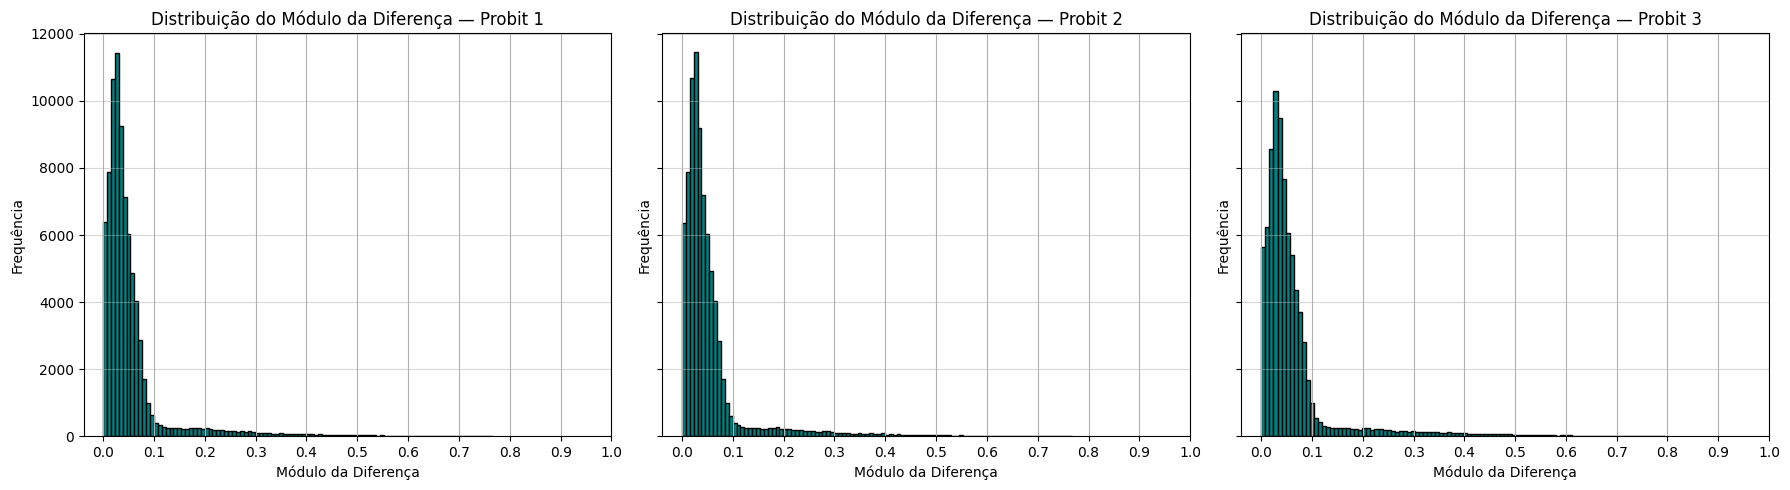

In [15]:
# calcular diferenças absolutas
df_t["abs_diff1"] = (df_t["Probit1"] - df_t["real"]).abs()
df_t["abs_diff2"] = (df_t["Probit2"] - df_t["real"]).abs()
df_t["abs_diff3"] = (df_t["Probit3"] - df_t["real"]).abs()

# imprimir médias
print(f"Média do Módulo da Diferença com probit 1: {df_t['abs_diff1'].mean():.4f}")
print(f"Média do Módulo da Diferença com probit 2: {df_t['abs_diff2'].mean():.4f}")
print(f"Média do Módulo da Diferença com probit 3: {df_t['abs_diff3'].mean():.4f}")

# painel com 3 histogramas lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

cols = [("abs_diff1", "Probit 1"), ("abs_diff2", "Probit 2"), ("abs_diff3", "Probit 3")]
for ax, (col, label) in zip(axes, cols):
    df_t[col].hist(bins=100, edgecolor='black', color='teal', ax=ax)
    ax.set_title(f'Distribuição do Módulo da Diferença — {label}', fontsize=12)
    ax.set_xlabel('Módulo da Diferença')
    ax.set_ylabel('Frequência')
    ax.grid(axis='y', alpha=0.5)
    ax.set_xticks(np.arange(0, 1.1, 0.1))

plt.tight_layout()
plt.show()

Eu havia feito uma análise com algumas métricas com os 3 modelos feitos até então e os resultados não foram muito bons, e particularmente no terceiro modelo o resultado piorou. Então para contornar o problema da alta correlação, decidi retirar uma das variáveis e adicionar um termo de interação. Para fazer a escolha da variável a ser retirada, vou fazer 3 modelos retirando cada uma das variáveis por vez:

In [16]:
X4 = X2.drop(X2.columns[[4]],axis=1)
teste4 = teste2.drop(teste2.columns[[4]],axis=1)
X4['interaction_term'] = X4.iloc[:,2] * X4.iloc[:,5]
teste4['interaction_term'] = teste4.iloc[:,2] * teste4.iloc[:,5]

X5 = X2.drop(X2.columns[[2]],axis=1)
teste5 = teste2.drop(teste2.columns[[2]],axis=1)
X5['interaction_term'] = X5.iloc[:,3] * X5.iloc[:,5]
teste5['interaction_term'] = teste5.iloc[:,3] * teste5.iloc[:,5]

X6 = X2.drop(X2.columns[[5]],axis=1)
teste6 = teste2.drop(teste2.columns[[5]],axis=1)
X6['interaction_term'] = X6.iloc[:,2] * X6.iloc[:,4]
teste6['interaction_term'] = teste6.iloc[:,2] * teste6.iloc[:,4]

probit_mode4 = sm.Probit(y, X4)
probit_result4 = probit_mode4.fit()
df_t['Probit4'] = probit_result4.predict(teste4)

probit_mode5 = sm.Probit(y, X5)
probit_result5 = probit_mode5.fit()
df_t['Probit5'] = probit_result5.predict(teste5)

probit_mode6 = sm.Probit(y, X6)
probit_result6 = probit_mode6.fit()
df_t['Probit6'] = probit_result6.predict(teste6)

Optimization terminated successfully.
         Current function value: 0.215652
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.215126
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.206074
         Iterations 7


In [17]:
n = len(df_t)

def adjusted_r2(y, yhat, p): #usando o R^2 pois cada modelo tem um número diferente de preditores
    if n - p - 1 <= 0:
        return float('nan')
    r2 = r2_score(y, yhat)
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

p1 = X1.shape[1] - 1
p2 = X2.shape[1] - 1
p3 = X3.shape[1] - 1
p4 = X4.shape[1] - 1
p5 = p4
p6 = p4

nds = pd.DataFrame({
    'Modelo': ['Probit 1', 'Probit 2', 'Probit 3', 'Probit 4', 'Probit 5', 'Probit 6'],
    'MSE': [
        mean_squared_error(df_t['real'], df_t['Probit1']),
        mean_squared_error(df_t['real'], df_t['Probit2']),
        mean_squared_error(df_t['real'], df_t['Probit3']),
        mean_squared_error(df_t['real'], df_t['Probit4']),
        mean_squared_error(df_t['real'], df_t['Probit5']),
        mean_squared_error(df_t['real'], df_t['Probit6'])
    ],
    'MAE': [
        mean_absolute_error(df_t['real'], df_t['Probit1']),
        mean_absolute_error(df_t['real'], df_t['Probit2']),
        mean_absolute_error(df_t['real'], df_t['Probit3']),
        mean_absolute_error(df_t['real'], df_t['Probit4']),
        mean_absolute_error(df_t['real'], df_t['Probit5']),
        mean_absolute_error(df_t['real'], df_t['Probit6'])
    ],
    'Corr (Pearson)': [
        df_t['real'].corr(df_t['Probit1']),
        df_t['real'].corr(df_t['Probit2']),
        df_t['real'].corr(df_t['Probit3']),
        df_t['real'].corr(df_t['Probit4']),
        df_t['real'].corr(df_t['Probit5']),
        df_t['real'].corr(df_t['Probit6'])
    ],
    'Adj R2': [
        adjusted_r2(df_t['real'], df_t['Probit1'], p1),
        adjusted_r2(df_t['real'], df_t['Probit2'], p2),
        adjusted_r2(df_t['real'], df_t['Probit3'], p3),
        adjusted_r2(df_t['real'], df_t['Probit4'], p4),
        adjusted_r2(df_t['real'], df_t['Probit5'], p5),
        adjusted_r2(df_t['real'], df_t['Probit6'], p6)
    ]

})

nds.head(6), probit_result6.summary()

(     Modelo       MSE       MAE  Corr (Pearson)    Adj R2
 0  Probit 1  0.008554  0.054500        0.546323  0.296927
 1  Probit 2  0.008562  0.054477        0.545712  0.296298
 2  Probit 3  0.011049  0.063528        0.313187  0.091890
 3  Probit 4  0.005880  0.042684        0.725298  0.516714
 4  Probit 5  0.004857  0.043407        0.776967  0.600817
 5  Probit 6  0.003540  0.035742        0.846317  0.709042,
 <class 'statsmodels.iolib.summary.Summary'>
 """
                           Probit Regression Results                           
 Dep. Variable:       SeriousDlqin2yrs   No. Observations:               120269
 Model:                         Probit   Df Residuals:                   120261
 Method:                           MLE   Df Model:                            7
 Date:                Mon, 10 Nov 2025   Pseudo R-squ.:                  0.1832
 Time:                        12:41:17   Log-Likelihood:                -24784.
 converged:                       True   LL-Null:       

Média do Módulo da Diferença com probit 6: 0.0357


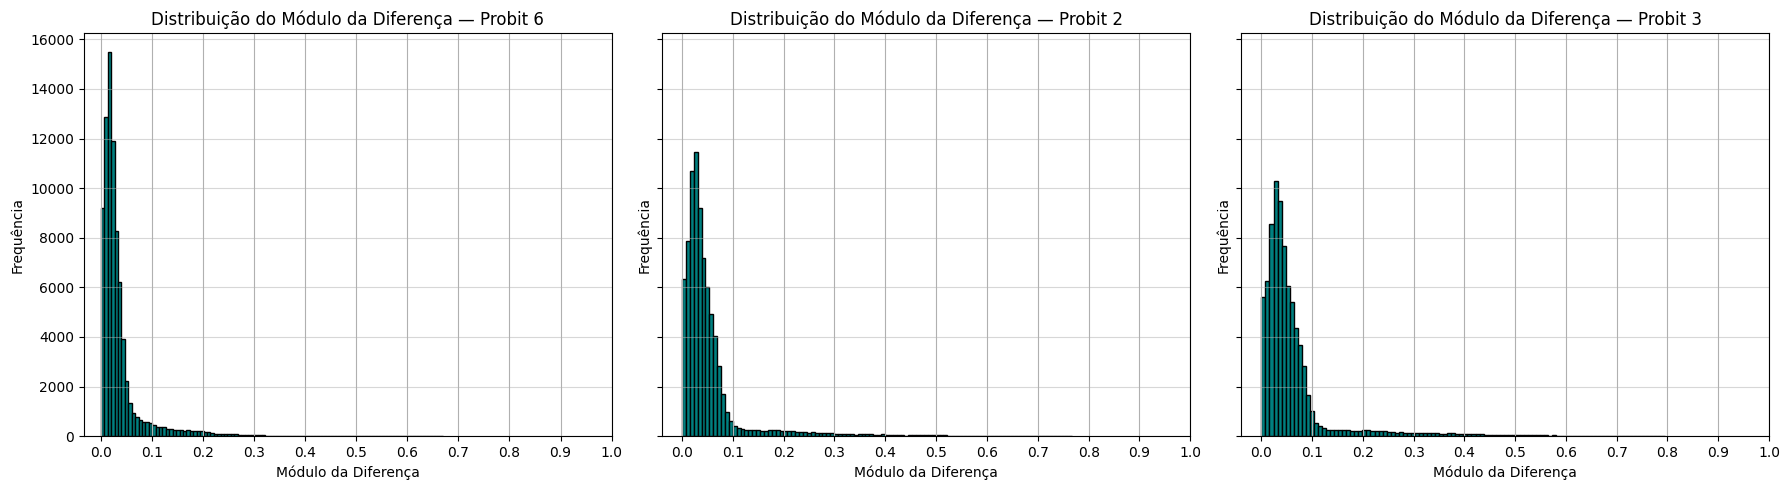

In [19]:
df_t["abs_diff2"] = (df_t["Probit2"] - df_t["real"]).abs()
df_t["abs_diff3"] = (df_t["Probit3"] - df_t["real"]).abs()
df_t["abs_diff6"] = (df_t["Probit6"] - df_t["real"]).abs()
print(f"Média do Módulo da Diferença com probit 6: {df_t['abs_diff6'].mean():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

cols = [("abs_diff6", "Probit 6"), ("abs_diff2", "Probit 2"), ("abs_diff3", "Probit 3")]
for ax, (col, label) in zip(axes, cols):
    df_t[col].hist(bins=100, edgecolor='black', color='teal', ax=ax)
    ax.set_title(f'Distribuição do Módulo da Diferença — {label}', fontsize=12)
    ax.set_xlabel('Módulo da Diferença')
    ax.set_ylabel('Frequência')
    ax.grid(axis='y', alpha=0.5)
    ax.set_xticks(np.arange(0, 1.1, 0.1))

plt.tight_layout()
plt.show()